In [1]:
from sklearn.preprocessing import StandardScaler

import numpy as np

In [2]:
import os

directory = './Dataset'
ext = ('.grib')

file = []

for files in os.listdir(directory):
    if (files.endswith(ext)):
        file.append(files)

print(file)

['pressure_and_evaporation_data.grib', 'precipitation_data.grib', 'temperature_data.grib', 'evap_total_cloud_2005-2024.grib']


In [3]:
# !pip install cfgrib
# !pip install xarray
import xarray as xr

grib_files = ['pressure_and_evaporation_data.grib',
              'temperature_data.grib',
              'evap_total_cloud_2005-2024.grib']


filePath = './Dataset/'

dataArray = []

for _, grib in enumerate(grib_files):
    # temp = xr.open_dataset(filePath + grib, engine='cfgrib')
    print(grib)
    # dataArray.append(xr.open_dataset(filePath + grib, engine='cfgrib'));
    # print(dataframes[-1].dims)
    


pressure_and_evaporation_data.grib
temperature_data.grib
evap_total_cloud_2005-2024.grib


In [4]:
pr = xr.open_dataset(filePath + 'precipitation_data.grib', engine='cfgrib')

pr

pr.close()

/home/htluu/.local/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


In [5]:
ds_pr = xr.open_dataset(filePath + 'precipitation_data.grib', engine='cfgrib')

valid_time = (ds_pr['time'].values[:, None] + ds_pr['step'].values[None, :]).ravel()

pr = ds_pr.stack(datetime=('time', 'step'))

pr = pr.assign_coords(valid_time=('datetime', valid_time))

pr = pr.swap_dims({'datetime': 'valid_time'})

pr = pr.drop_vars(['time', 'step', 'datetime'], errors='ignore')

pr = pr.rename({'valid_time': 'time'})

pr

ds_pr.close()

/home/htluu/.local/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


In [6]:
ds_t = xr.open_dataset(filePath + grib_files[1], engine='cfgrib')

temp = ds_t.drop_vars(['step', 'valid_time'], errors='ignore')

temp

ds_t.close()

/home/htluu/.local/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


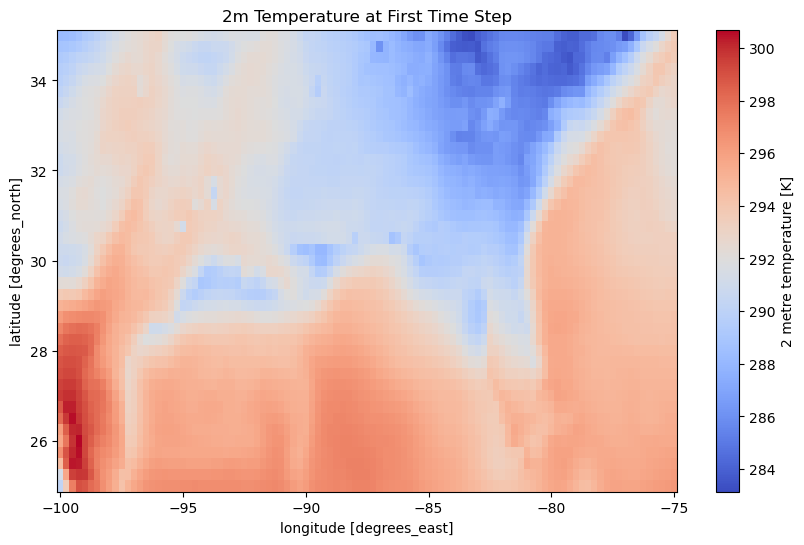

In [7]:
import matplotlib.pyplot as plt


var = temp['t2m']
single_time = var.isel(time=0)

plt.figure(figsize=(10, 6))
single_time.plot(cmap='coolwarm')
plt.title('2m Temperature at First Time Step')
plt.show()

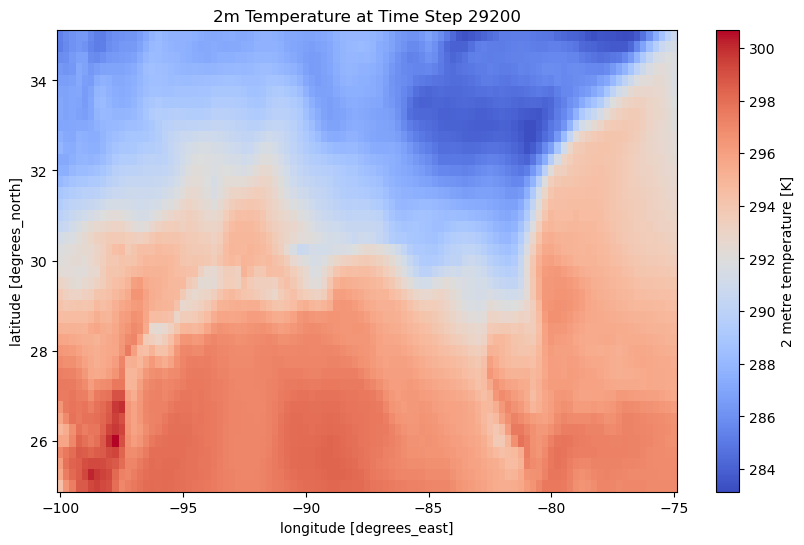

In [8]:
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(10, 6))

plot = var.isel(time=0).plot(ax=ax, cmap='coolwarm', add_colorbar=True)
title = ax.set_title(f"Temperature at Time Step 0")

def update(frame):
    ax.clear()
    plot = var.isel(time=frame).plot(ax=ax, cmap='coolwarm', add_colorbar=False)
    ax.set_title(f"2m Temperature at Time Step {frame}")
    return plot
    
anim = FuncAnimation(fig, update, frames=range(0, len(var.time), 100), interval=200)
anim.save("Animation/t2m_animation_2.gif", writer="pillow", fps=5) 
plt.show()

In [9]:
var = temp
temp_data = var.stack(points=("latitude", "longitude")).transpose("time", "points").values

data_scaled = temp_data #StandardScaler().fit_transform(temp_data)


In [10]:
# # https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html
# # https://www.dbs.ifi.lmu.de/Publikationen/Papers/KDD-96.final.frame.pdf

# eps = 2 #distance between samples
# min_samples = 2 #higher value -> denser cluster
# metric = 'euclidean'

# cluster = DBSCAN(eps = eps, min_samples = min_samples, metric = metric).fit(data_scaled)
# labels = cluster.labels_

# import pandas as pd
# import matplotlib.pyplot as plt

# time = temp['time'].values
# labels_series = pd.Series(labels, index=pd.to_datetime(time))

# plt.figure(figsize=(12, 6))
# labels_series.groupby(labels_series.index).apply(lambda x: x.value_counts()).unstack().plot()
# plt.title('Cluster Occurrence Over Time')
# plt.xlabel('Time')
# plt.ylabel('Count')
# plt.legend(title='Cluster')
# plt.show()

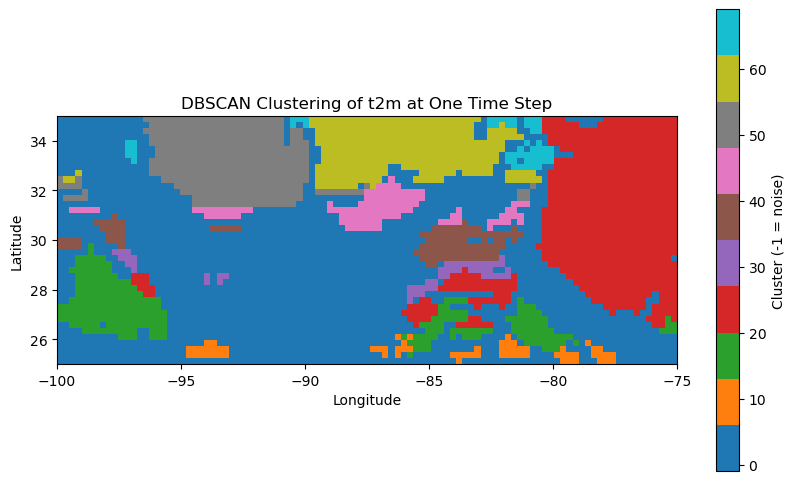

In [11]:
from sklearn.cluster import DBSCAN

t2m = temp['t2m'].isel(time=0)

lat, lon = np.meshgrid(t2m.latitude.values, t2m.longitude.values, indexing='ij')

features = np.stack([lat.ravel(), lon.ravel(), t2m.values.ravel()], axis=1)

features_valid = features[~np.isnan(features).any(axis=1)]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_valid)

eps = .1 #distance between samples
min_samples = 5 #higher value -> denser cluster
metric = 'euclidean'

db = DBSCAN(eps=eps, min_samples=min_samples, metric=metric).fit(features_scaled)
labels = db.labels_

label_grid = np.full(t2m.size, fill_value=-1)
label_grid[~np.isnan(t2m.values.ravel())] = labels
label_grid = label_grid.reshape(t2m.shape)

plt.figure(figsize=(10, 6))
plt.imshow(label_grid, origin='lower', cmap='tab10', extent=[t2m.longitude.min(), t2m.longitude.max(), t2m.latitude.min(), t2m.latitude.max()])
plt.colorbar(label='Cluster (-1 = noise)')
plt.title("DBSCAN Clustering of t2m at One Time Step")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

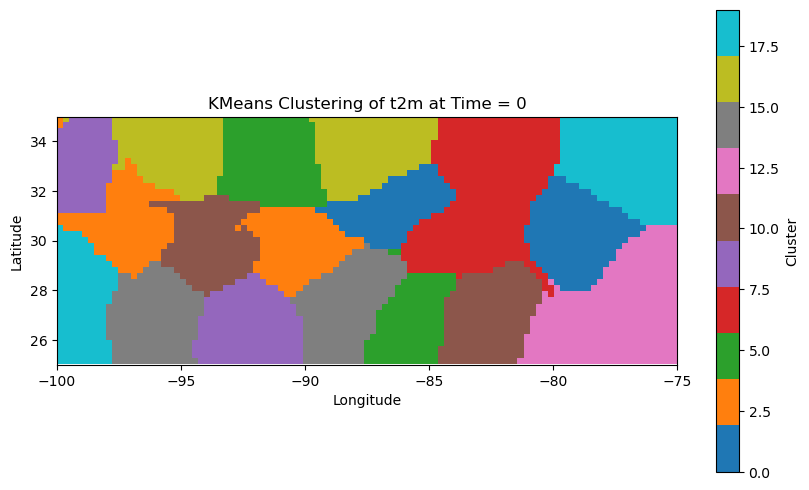

In [12]:
from sklearn.cluster import KMeans

t2m = temp['t2m'].isel(time=0)

lat, lon = np.meshgrid(t2m.latitude.values, t2m.longitude.values, indexing='ij')
X = np.stack([lat.ravel(), lon.ravel(), t2m.values.ravel()], axis=1)

X = X[~np.isnan(X).any(axis=1)]

n_clusters = 20
kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(X)

labels = np.full(t2m.shape, -1)
flat_indices = ~np.isnan(t2m.values.ravel())
labels_flat = np.full_like(t2m.values.ravel(), -1, dtype=int)
labels_flat[flat_indices] = kmeans.labels_
labels = labels_flat.reshape(t2m.shape)

plt.figure(figsize=(10, 6))
plt.imshow(labels, origin='lower', cmap='tab10', extent=[t2m.longitude.min(), t2m.longitude.max(), t2m.latitude.min(), t2m.latitude.max()])
plt.colorbar(label='Cluster')
plt.title("KMeans Clustering of t2m at Time = 0")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [13]:
# test = xr.open_dataarray(filePath + 'precipitation_data.grib', engine='cfgrib')

# test_df = test.to_dataframe()

# print(test_df.describe())
# print(test.coords['step'])

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Extract one time slice (assuming temp is a Dataset with variables: 't2m', 'd2m', 'sst')
t2m = temp['t2m'].isel(time=0)
d2m = temp['d2m'].isel(time=0)
# sst = temp['sst'].isel(time=0)

# Create lat/lon grid
lat, lon = np.meshgrid(t2m.latitude.values, t2m.longitude.values, indexing='ij')

# Flatten the data into a feature array: (lat, lon, d2m, t2m, sst)
features = np.stack([
    lat.ravel(),
    lon.ravel(),
    d2m.values.ravel(),
    t2m.values.ravel(),
    sst.values.ravel()
], axis=1)

# Filter out NaN rows
features_valid = features[~np.isnan(features).any(axis=1)]

# Normalize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_valid)

# Run DBSCAN
db = DBSCAN(eps=0.3, min_samples=3, metric='euclidean')
labels = db.fit_predict(features_scaled)

# Create NaN mask based on all features, not just t2m
nan_mask = np.isnan(features).any(axis=1)
valid_mask = ~nan_mask

# Initialize label grid and fill only valid positions
label_grid = np.full(t2m.size, fill_value=-1)
label_grid[valid_mask] = labels
label_grid = label_grid.reshape(t2m.shape)

# Plotting
plt.figure(figsize=(10, 6))
plt.imshow(label_grid, origin='lower', cmap='tab10', extent=[
    t2m.longitude.min(), t2m.longitude.max(),
    t2m.latitude.min(), t2m.latitude.max()
])
plt.colorbar(label='Cluster Label (-1 = noise)')
plt.title("DBSCAN Clustering of Multi-Field Data at One Time Step")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


NameError: name 'sst' is not defined